# Matplotlib Figures and Axes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

```{contents}
:local:
:depth: 2
```


```{index} object-oriented interface, figure, axes
```
## Object-Oriented Plotting with `plt.subplots()`


::: {note}
But what's the difference between a **figure** and an **axes**?

| | **Figure** | **Axes** |
|---|---|---|
| Analogy | The full canvas/window | One plot region on that canvas |
| What it is | The top-level container | The area where data is drawn |
| Contains | One or more Axes | X/Y axis, ticks, lines, labels, title, legend |
| Commonly created by | `plt.figure()` or `plt.subplots()` | returned by `plt.subplots()` or added to a figure |

A good mental model is:

```text
Figure
└── Axes (a.k.a. one plot)
    ├── XAxis
    ├── YAxis
    ├── Title
    ├── Lines / Bars / etc.
    └── Legend
```
:::



Here we will learn two OO workflows:

- `plt.subplots()` for the standard, everyday workflow
- `plt.figure()` + `fig.add_axes()` for manual placement and inset-style layouts



```{index} subplots (plt.subplots), tight layout (tight_layout), figure title (suptitle), shared axis (sharey)
```
### `plt.subplots()`

`plt.subplots()` creates the **figure** and **axes** objects in one step and returns them as a tuple.

- If you create a single subplot, you typically get one `Axes` object.
- If you create multiple subplots, you get a NumPy array of `Axes` objects.

Typical syntax:

`fig, ax = plt.subplots()`

The example below shows the standard one-axes case.


Text(0.5, 1.0, 'Monthly Revenue')

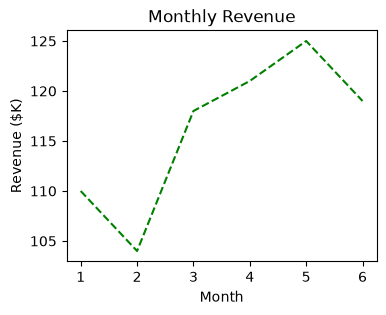

In [2]:
month = np.arange(1, 7)                               ### months 1 to 6 (Jan to Jun)
revenue = np.array([110, 104, 118, 121, 125, 119])    ### monthly revenue in $K

# fig, ax = plt.subplots()              ### single Axes case
# fig, axes = plt.subplots(1, 2)        ### multiple Axes case

fig, ax = plt.subplots(figsize=(4,3))   ### unpacking in one step
ax.plot(month, revenue, 'g--')          ### plot on that axes

### common axes methods
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($K)')
ax.set_title('Monthly Revenue')

With `subplots()`, you can specify the number of rows and columns using the `nrows=` and `ncols=` parameters when creating the subplots() object. The example below creates an empty canvas of 1-row by 2-cols subplots. 

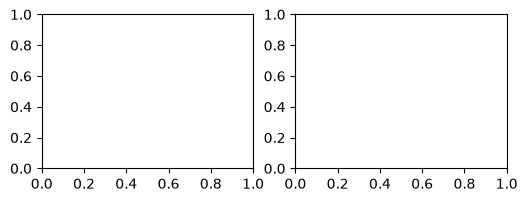

In [3]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2))  ### similar to plt.subplot(1, 2, ith axes)
# fig, axes = plt.subplots(1, 2)            ### same as above

In this example above, `axes` is an array variable containing two `Axes` objects. Looping over that array is a common pattern when you want to apply the same formatting to each subplot.

In [4]:
print(axes)

[<Axes: > <Axes: >]


Now we have access over the two Axes individually using **indexing** (`[0] and [1]`). We may plot them separately.

Text(0.5, 1.0, 'Store B')

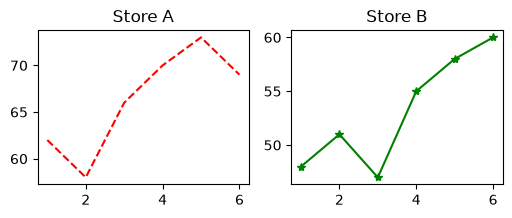

In [5]:
month = np.arange(1, 7)
store_a = np.array([62, 58, 66, 70, 73, 69])          ### monthly sales in $K
store_b = np.array([48, 51, 47, 55, 58, 60])

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2))

axes[0].plot(month, store_a, 'r--')    ### plot on the first axes
axes[0].set_title('Store A')           ### set title for the first axes

axes[1].plot(month, store_b, 'g*-')    ### plot on the second axes
axes[1].set_title('Store B')           ### set title for the second axes

It's not uncommon to loop through the Axes object then fine tune the plots. `zip()` pairs each axes with its data and title, so one loop formats both charts.

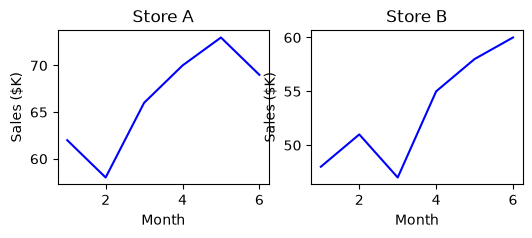

In [6]:
month = np.arange(1, 7)
store_a = np.array([62, 58, 66, 70, 73, 69])          ### monthly sales in $K
store_b = np.array([48, 51, 47, 55, 58, 60])

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2))

for ax, sales, name in zip(axes, [store_a, store_b], ['Store A', 'Store B']):
    ax.plot(month, sales, 'b')
    ax.set_xlabel('Month')
    ax.set_ylabel('Sales ($K)')
    ax.set_title(name)

plt.show()


A common issue in Matplotlib is overlapping subplot labels or titles. `plt.tight_layout()` can automatically adjust spacing so the figure is easier to read. (compare with the plots above)


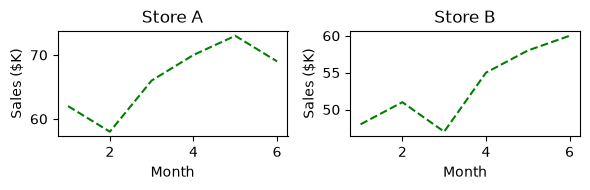

In [7]:
month = np.arange(1, 7)
store_a = np.array([62, 58, 66, 70, 73, 69])          ### monthly sales in $K
store_b = np.array([48, 51, 47, 55, 58, 60])

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2))

for ax, sales, name in zip(axes, [store_a, store_b], ['Store A', 'Store B']):
    ax.plot(month, sales, 'g--')
    ax.set_xlabel('Month')
    ax.set_ylabel('Sales ($K)')
    ax.set_title(name)

plt.tight_layout()                     ### fix overlapping labels and titles

Each `ax.set_title()` names one axes. To give the whole figure one title, use `fig.suptitle()`, which places the title above all the subplots. This is common in dashboards, where several charts support one message. The x values here are quarter labels rather than numbers; Matplotlib places text labels along the axis in the order given. `sharey=True` gives every subplot the same y-axis range. Without it, each subplot scales to its own data, and a small region can look as large as a big one.


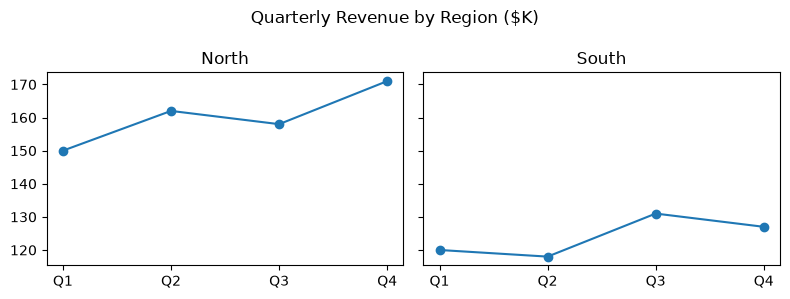

In [8]:
quarters = ["Q1", "Q2", "Q3", "Q4"]
north = [150, 162, 158, 171]
south = [120, 118, 131, 127]

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)   ### sharey: same y scale for a fair comparison

axes[0].plot(quarters, north, marker='o')
axes[0].set_title('North')

axes[1].plot(quarters, south, marker='o')
axes[1].set_title('South')

fig.suptitle('Quarterly Revenue by Region ($K)')   ### one title for the whole figure
plt.tight_layout()


In [9]:
### Exercise: Side-by-Side Subplots with plt.subplots()
#   1. Create month = np.arange(1, 7),
#      east = np.array([95, 99, 104, 101, 110, 116]), and
#      west = np.array([70, 68, 74, 79, 77, 83]).
#   2. Use plt.subplots(1, 2, figsize=(8, 3)) to create a figure and two axes.
#   3. On axes[0], plot month vs east with 'b-', title "East",
#      x-label "Month", and y-label "Revenue ($K)".
#   4. On axes[1], plot month vs west with 'r--', title "West",
#      x-label "Month", and y-label "Revenue ($K)".
#   5. Call plt.tight_layout() at the end.
### Your code starts here.




### Your code ends here.

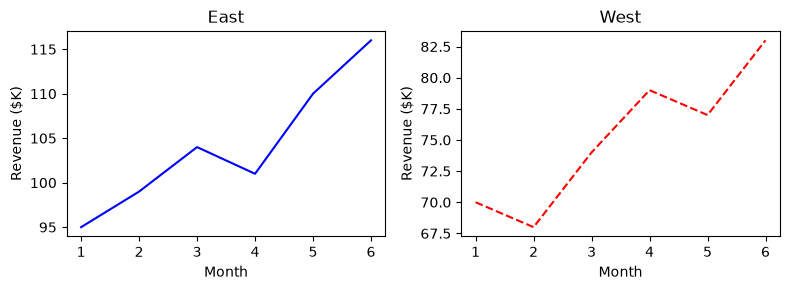

In [10]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

month = np.arange(1, 7)
east = np.array([95, 99, 104, 101, 110, 116])
west = np.array([70, 68, 74, 79, 77, 83])

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].plot(month, east, 'b-')
axes[0].set_title('East')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue ($K)')
axes[1].plot(month, west, 'r--')
axes[1].set_title('West')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Revenue ($K)')
plt.tight_layout()
plt.show()


```{index} add axes (add_axes), inset axes
```
## Manual Placement with `add_axes()`

`fig.add_axes()` is a more manual OO technique than `plt.subplots()`. It is most useful when you want precise axes placement, such as inset plots or custom layouts.

The process of using `add_axes()` to create plots is:

1. Create a **Figure** object.
2. Add one or more **Axes** using normalized figure coordinates `[left, bottom, width, height]`.
3. Plot and format each axes separately.


`add_axes()` uses normalized figure coordinates. For example, `[0.1, 0.1, 0.8, 0.8]` means:

- left edge at 10% of the figure width
- bottom edge at 10% of the figure height
- axes width equal to 80% of the figure width
- axes height equal to 80% of the figure height


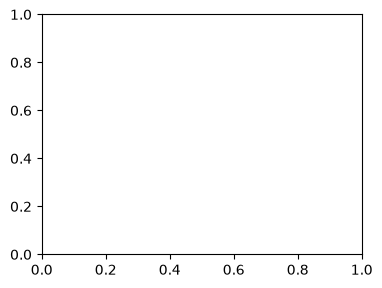

In [11]:
fig = plt.figure(figsize=(4,3))             ### 1. create an empty figure
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])     ### 2. add one axes using normalized coordinates



While slightly more involved, `add_axes()` gives you precise control over where each axes sits in the figure. That makes it a good choice for inset plots and manually arranged layouts.


Text(0.5, 1.0, 'Promotion Week')

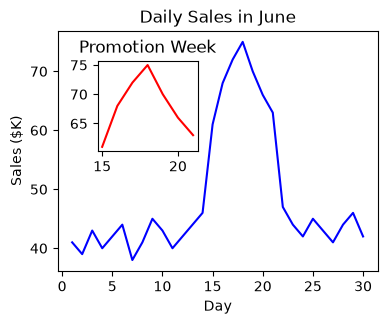

In [12]:
day = np.arange(1, 31)                  ### days in June
daily_sales = np.array([41, 39, 43, 40, 42, 44, 38, 41, 45, 43,
                        40, 42, 44, 46, 61, 68, 72, 75, 70, 66,
                        63, 47, 44, 42, 45, 43, 41, 44, 46, 42])   ### $K; promotion on days 15-21

fig = plt.figure(figsize=(4,3))         ### create empty canvas on the figure (object)

### add two axes to the figure
axes1 = fig.add_axes([0.1, 0.1, 0.8, 0.8])     ### main axes
axes2 = fig.add_axes([0.2, 0.5, 0.25, 0.3])    ### inset axes, over the flat early days

### main axes: the whole month
axes1.plot(day, daily_sales, 'b')
axes1.set_xlabel('Day')
axes1.set_ylabel('Sales ($K)')
axes1.set_title('Daily Sales in June')

### inset axes: zoom in on the promotion week
axes2.plot(day[14:21], daily_sales[14:21], 'r')
axes2.set_title('Promotion Week')

In [13]:
### Exercise: Figure with Main Plot and Inset using plt.figure()
#   1. Create month = np.arange(1, 7),
#      units = np.array([540, 510, 580, 600, 620, 590]), and
#      returns = np.array([22, 25, 19, 18, 21, 17]).
#   2. Create a figure with figsize=(4, 3).
#   3. Add a main axes at [0.1, 0.1, 0.8, 0.8] and plot month vs units in blue.
#      Set the title to "Units Sold".
#   4. Add an inset axes at [0.55, 0.15, 0.3, 0.3] and plot month vs returns in red.
#      Set the title to "Returns".
### Your code starts here.




### Your code ends here.

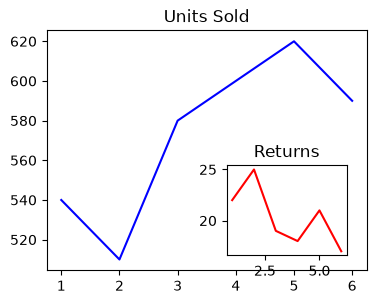

In [14]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

month = np.arange(1, 7)
units = np.array([540, 510, 580, 600, 620, 590])
returns = np.array([22, 25, 19, 18, 21, 17])

fig = plt.figure(figsize=(4, 3))
main_ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
main_ax.plot(month, units, color='blue')
main_ax.set_title('Units Sold')
inset_ax = fig.add_axes([0.55, 0.15, 0.3, 0.3])
inset_ax.plot(month, returns, color='red')
inset_ax.set_title('Returns')
plt.show()

```{index} figure-level settings
```
## Figure Size, Resolution, and Saving

Three figure-level settings decide how a chart looks outside the notebook: its size in inches, its resolution in dots per inch, and the file it is saved to. These matter most when a chart goes into a report or slide deck.


```{index} figure size (figsize)
```
### `figsize=`

Figure size and DPI are two of the most common figure-level controls.

- `figsize=(width, height)` uses inches.

This can be set with `plt.figure(...)` or `plt.subplots(...)`.


Text(0.5, 1.0, 'Monthly Revenue')

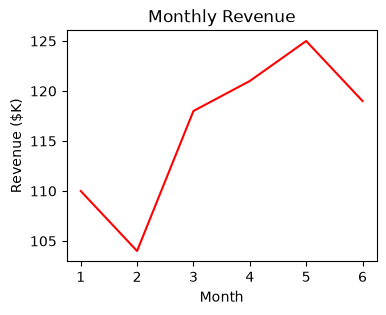

In [15]:
month = np.arange(1, 7)                               ### months 1 to 6 (Jan to Jun)
revenue = np.array([110, 104, 118, 121, 125, 119])    ### monthly revenue in $K

fig, axes = plt.subplots(figsize=(4,3))

### peripherals for the axes object
axes.plot(month, revenue, 'r')
axes.set_xlabel('Month')
axes.set_ylabel('Revenue ($K)')
axes.set_title('Monthly Revenue')

```{index} DPI, resolution
```
### DPI

- `dpi` sets dots per inch, which affects rendered resolution.

Text(0.5, 1.0, 'Monthly Revenue')

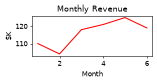

In [16]:
month = np.arange(1, 7)                               ### months 1 to 6 (Jan to Jun)
revenue = np.array([110, 104, 118, 121, 125, 119])    ### monthly revenue in $K

fig = plt.figure(figsize=(3,1), dpi=50)          ### low resolution
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])
axes.plot(month, revenue, 'r')
axes.set_xlabel('Month')
axes.set_ylabel('$K')
axes.set_title('Monthly Revenue')

Text(0.5, 1.0, 'Monthly Revenue')

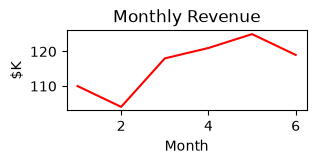

In [17]:
month = np.arange(1, 7)                               ### months 1 to 6 (Jan to Jun)
revenue = np.array([110, 104, 118, 121, 125, 119])    ### monthly revenue in $K

fig = plt.figure(figsize=(3,1), dpi=100)         ### same size, twice the resolution
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])
axes.plot(month, revenue, 'r')
axes.set_xlabel('Month')
axes.set_ylabel('$K')
axes.set_title('Monthly Revenue')

In [18]:
### Exercise: Setting Figure Size and DPI
#   1. Create month = np.arange(1, 7) and
#      revenue = np.array([110, 104, 118, 121, 125, 119]).
#   2. Create a figure with figsize=(4, 3) and dpi=150.
#   3. Add axes using fig.add_axes([0.1, 0.1, 0.8, 0.8]).
#   4. Plot month vs revenue with a green line.
#   5. Set the title to "Monthly Revenue".
### Your code starts here.




### Your code ends here.

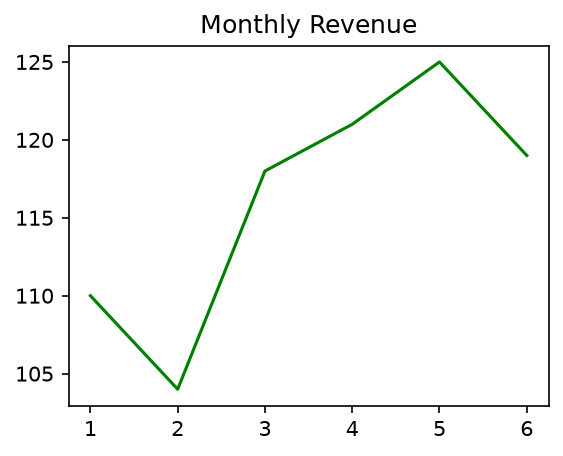

In [19]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

month = np.arange(1, 7)
revenue = np.array([110, 104, 118, 121, 125, 119])

fig = plt.figure(figsize=(4, 3), dpi=150)
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
ax.plot(month, revenue, color='green')
ax.set_title('Monthly Revenue')
plt.show()

```{index} saving figures (savefig)
```
### Saving Figures

Matplotlib can save high-quality output in formats such as PNG, JPG, SVG, and PDF.


Use the figure's `.savefig()` method. The file type follows the extension, such as `.png`, `.pdf`, or `.svg`. Use `dpi=` to set the resolution of the saved file: the default is about 100 dots per inch, which looks fine on screen, while 200 to 300 is typical for printed reports. In the example below, we create a small figure explicitly before saving it:


Saved: ../../_build/generated/monthly_revenue.png


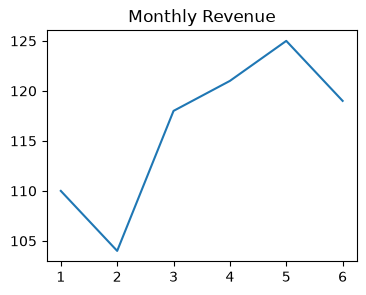

In [20]:
import os
output_dir = '../../_build/generated'
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, 'monthly_revenue.png')

month = np.arange(1, 7)                               ### months 1 to 6 (Jan to Jun)
revenue = np.array([110, 104, 118, 121, 125, 119])    ### monthly revenue in $K

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(month, revenue)
ax.set_title('Monthly Revenue')

fig.savefig(output_file, dpi=200)     ### dpi= sets the resolution of the saved file
print(f"Saved: {output_file}")

In [21]:
### Exercise: Save a Chart for a Report
#   1. Create quarters = ["Q1", "Q2", "Q3", "Q4"] and revenue = [120, 135, 128, 150].
#   2. Use fig, ax = plt.subplots(figsize=(6, 3)) and plot quarters vs revenue
#      with circle markers (marker='o').
#   3. Set the title "Quarterly Revenue".
#   4. Save the figure as "quarterly_revenue.png" with dpi=150.
### Your code starts here.




### Your code ends here.


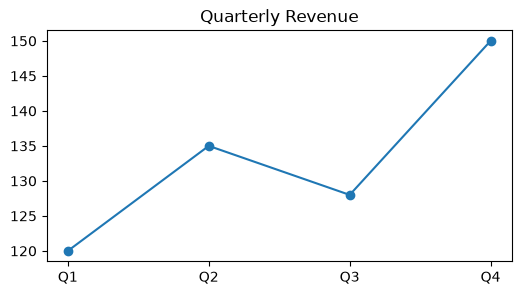

In [22]:
### Solution
quarters = ["Q1", "Q2", "Q3", "Q4"]
revenue = [120, 135, 128, 150]

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(quarters, revenue, marker='o')
ax.set_title("Quarterly Revenue")
fig.savefig("quarterly_revenue.png", dpi=150)


## Summary

- A **figure** is the whole canvas; an **axes** is one chart on it. Most formatting is done with axes methods such as `ax.set_title()`, `ax.set_xlabel()`, and `ax.set_ylabel()`.
- `fig, ax = plt.subplots()` creates one chart. `fig, axes = plt.subplots(nrows, ncols)` returns an array of axes that you can index (`axes[0]`) or loop over with `zip()`.
- `plt.tight_layout()` fixes overlapping labels, `fig.suptitle()` titles the whole figure, and `sharey=True` puts subplots on the same scale so they compare fairly.
- `fig.add_axes([left, bottom, width, height])` places an axes by fractions of the figure, which is how inset charts are made.
- `figsize=` sets size in inches and `dpi=` sets resolution. `fig.savefig("file.png", dpi=200)` saves a chart for a report; the file extension sets the format.

## Further Reading

- [Arranging multiple Axes in a Figure](https://matplotlib.org/stable/users/explain/axes/arranging_axes.html): grids, shared axes, and more layout options than `plt.subplots()`.
- [`Figure.add_axes`](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.add_axes.html): the full reference for manual axes placement.
- [`Figure.savefig`](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.savefig.html): file formats, resolution, transparent backgrounds, and cropping options.